In [1]:
import lightkurve as lk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import astroquery
import astropy
from astropy.table import Table

C:\Users\giahy\Downloads\anaconda\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
from astroquery.nasa_exoplanet_archive import NasaExoplanetArchive

#get table from nasa database
koi_table = NasaExoplanetArchive.query_criteria(
    table="koi",
    select="kepid, kepoi_name, koi_period, koi_disposition, koi_kepmag",
    where="koi_disposition like 'CANDIDATE' and koi_kepmag < 14"
)

#convert to dataframe
df = koi_table.to_pandas()
print(f"Found {len(df)} candidate stars")
print(df.head())

C:\Users\giahy\AppData\Local\Temp\ipykernel_22524\26432046.py:1: DeprecationWarning: the ``nasa_exoplanet_archive`` module has been moved to astroquery.ipac.nexsci.nasa_exoplanet_archive, please update your imports.
  from astroquery.nasa_exoplanet_archive import NasaExoplanetArchive


Found 3255 candidate stars
      kepid kepoi_name  koi_period koi_disposition  koi_kepmag
0   9579641  K00115.03    3.435916       CANDIDATE      12.791
1  10460629  K01168.01  856.672115       CANDIDATE      13.997
2  10319385  K01169.01    0.689210       CANDIDATE      13.248
3  11502218  K00970.01    3.988602       CANDIDATE       6.974
4  11180361  K00971.01    0.533059       CANDIDATE       7.748


In [3]:
#sort and pick top 50 only
df_sorted = df.sort_values('koi_kepmag', ascending=True)
df_sample = df_sorted.head(50).reset_index(drop=True)

#print range and 10 first stars
print(f"Working sample: {len(df_sample)} stars")
print(f"Brightness range: {df_sample['koi_kepmag'].min():.1f} to {df_sample['koi_kepmag'].max():.1f}")
print(df_sample[['kepid', 'kepoi_name', 'koi_period', 'koi_kepmag']].head(10))

Working sample: 50 stars
Brightness range: 7.0 to 10.1
      kepid kepoi_name  koi_period  koi_kepmag
0  11502218  K00970.01    3.988602       6.974
1  11502218  K00970.01    3.988602       6.974
2  11180361  K00971.01    0.533059       7.748
3  11180361  K00971.01    0.533059       7.748
4  11180361  K00971.01    0.533059       7.748
5   5108214  K01924.01    2.119128       7.837
6   5108214  K01924.01    2.119130       7.837
7   4150611  K03156.04   94.224542       7.899
8   4150611  K03156.01    0.761122       7.899
9   4150611  K03156.01    0.761120       7.899


Processing 1/50: KIC 11502218... Error: 'detected_period', skipping
Processing 2/50: KIC 11502218... Error: 'detected_period', skipping
Processing 3/50: KIC 11180361... Error: 'detected_period', skipping
Processing 4/50: KIC 11180361... Error: 'detected_period', skipping
Processing 5/50: KIC 11180361... Error: 'detected_period', skipping
Processing 6/50: KIC 5108214... Error: 'detected_period', skipping
Processing 7/50: KIC 5108214... Error: 'detected_period', skipping
Processing 8/50: KIC 4150611... Error: 'detected_period', skipping
Processing 9/50: KIC 4150611... Error: 'detected_period', skipping
Processing 10/50: KIC 4150611... Error: 'detected_period', skipping
Processing 11/50: KIC 6032730... Error: 'detected_period', skipping
Processing 12/50: KIC 6032730... Error: 'detected_period', skipping
Processing 13/50: KIC 6032730... Error: 'detected_period', skipping
Processing 14/50: KIC 11709006... Error: 'detected_period', skipping
Processing 15/50: KIC 7022603... Error: 'detected_p

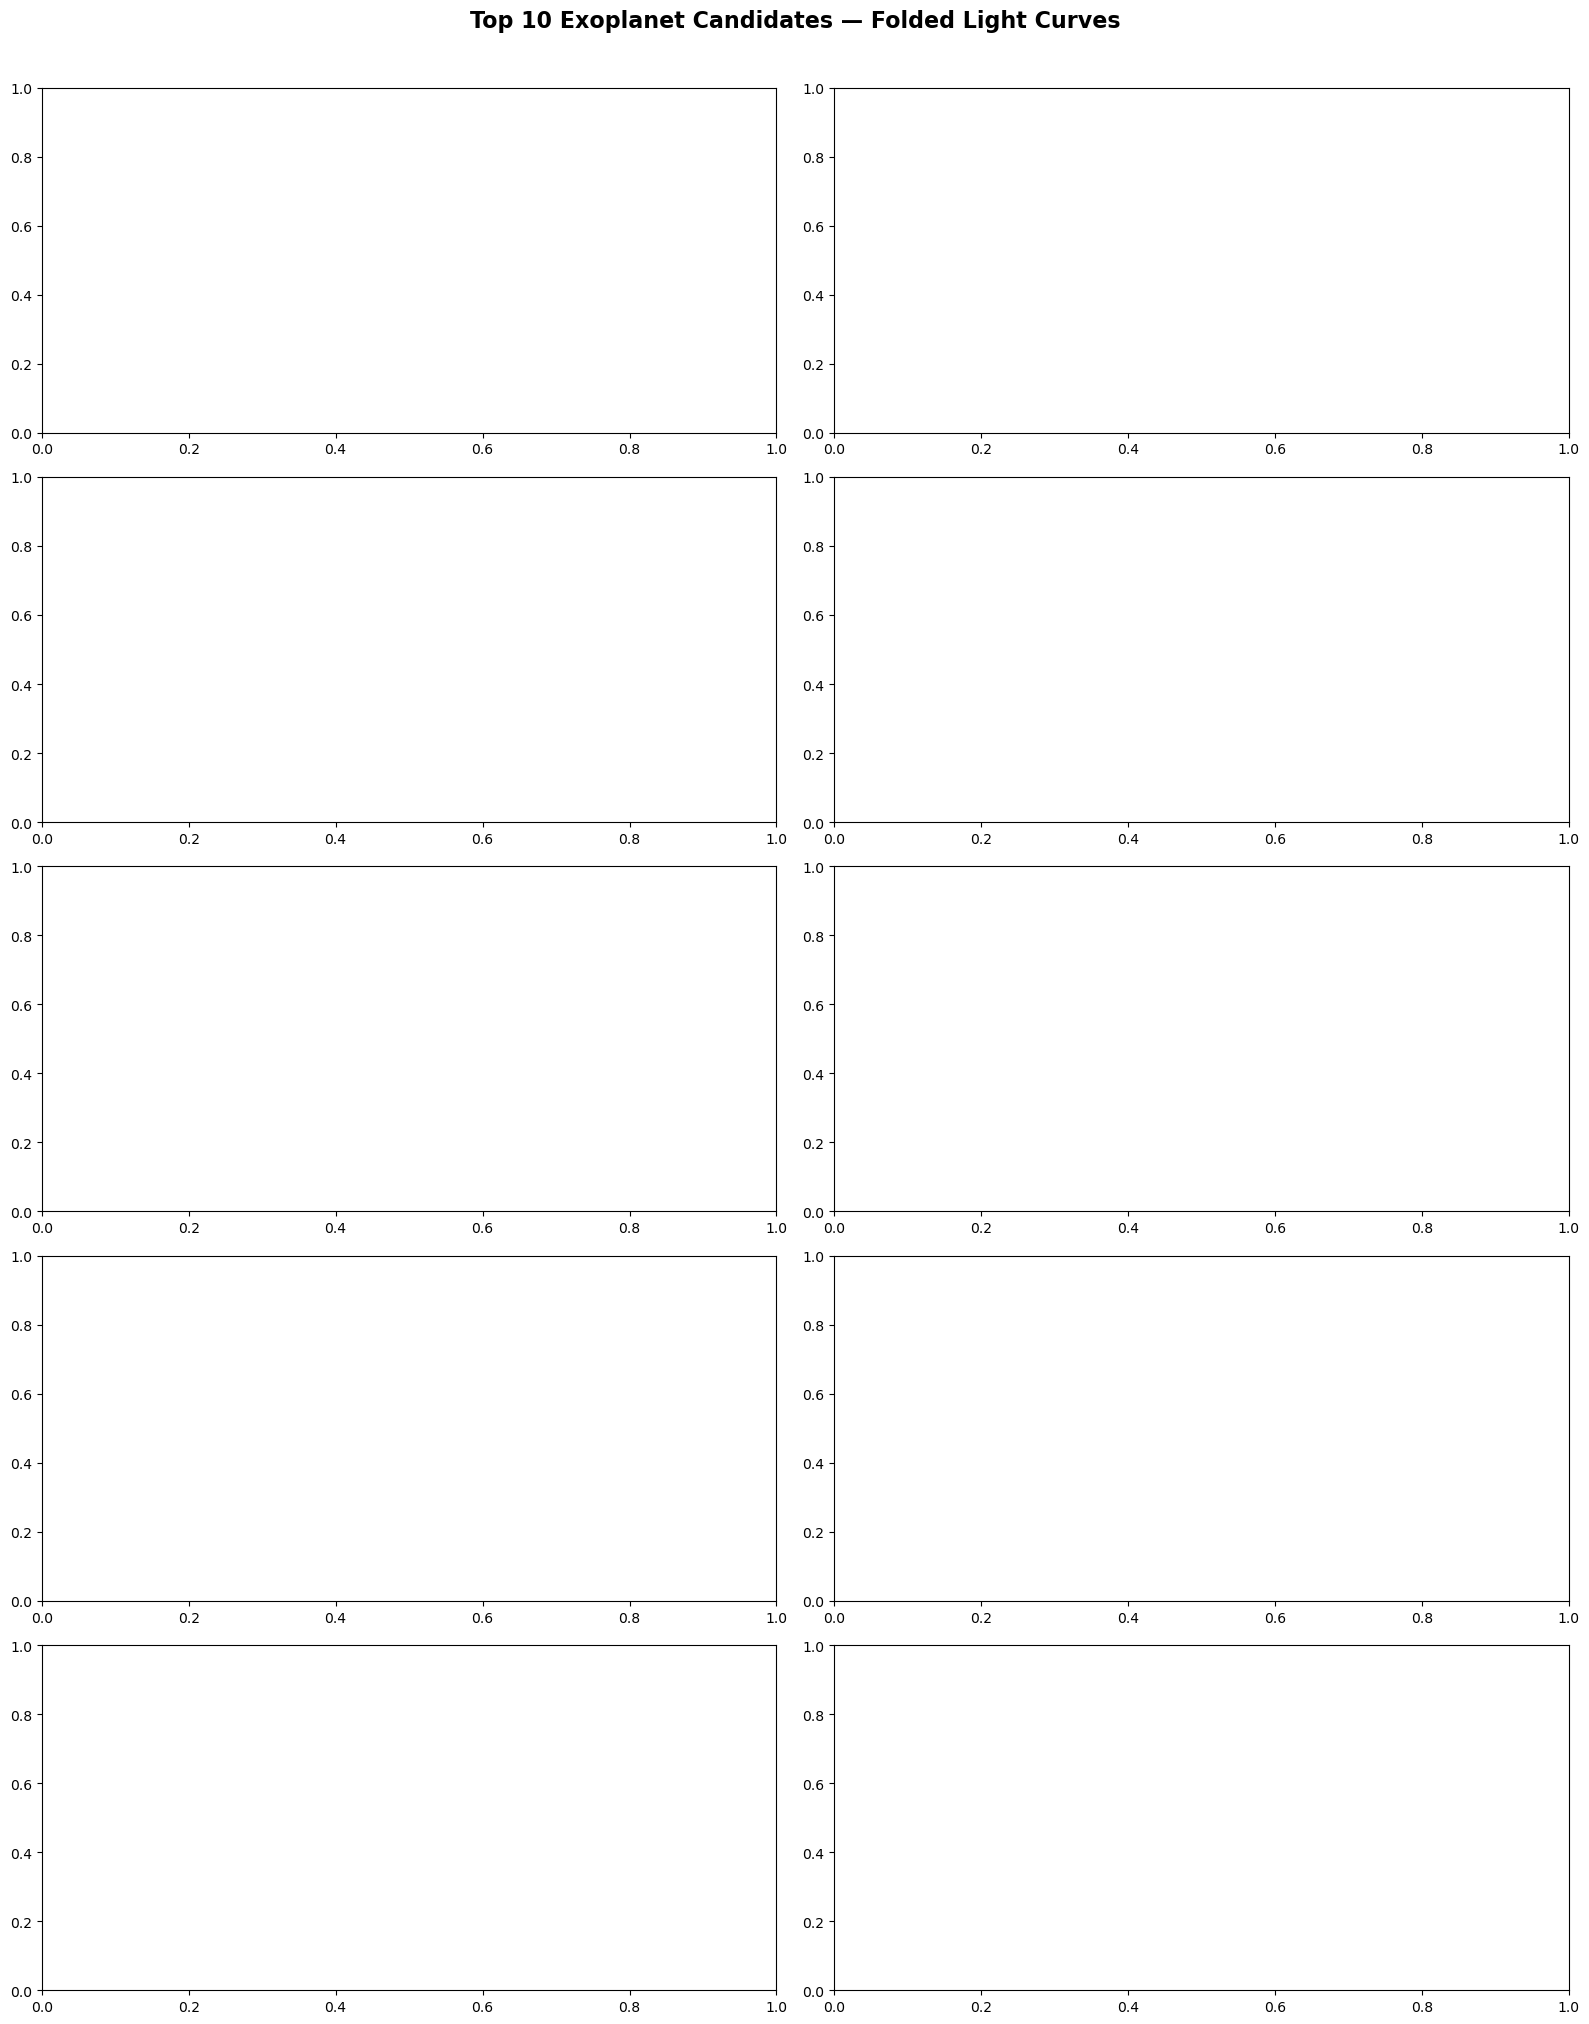

Plot saved to outputs/v2_top10_folded.png

Pipeline complete. Processed 0 stars successfully.
Empty DataFrame
Columns: []
Index: []


In [20]:
results = []

#go over every row and get that star's lightcurve
for idx, row in df_sample.iterrows():
    kepid = str(int(row['kepid']))
    print(f"Processing {idx+1}/50: KIC {kepid}...", end=" ")
    
    try:
        search = lk.search_lightcurve(
            f"KIC {kepid}", 
            mission="Kepler", 
            cadence="long"
        )
        
        if len(search) == 0:
            print("No data found, skipping")
            continue
            
        lc = search[0].download()

        #clean and save period
        lc = lc.remove_nans().remove_outliers(sigma=3).normalize()
        
        pg = lc.to_periodogram(
            method="bls",
            period=np.arange(0.5, 30, 0.01)
        )

        best_period = pg.period_at_max_power.value
        best_power = pg.max_power.value

        #save to results list
        results.append({
            'kepid': kepid,
            'kepoi_name': row['kepoi_name'],
            'detected_period': round(best_period, 4),
            'catalog_period': round(row['koi_period'], 4),
            'bls_power': round(best_power, 4),
            'koi_kepmag': round(row['koi_kepmag'], 2),
            'data_points': len(lc)
        })
        
        print(f"Period: {best_period:.3f} days, Power: {best_power:.4f}")
        
    except Exception as e:
        print(f"Error: {e}, skipping")
        continue

print(f"\nPipeline complete. Processed {len(results)} stars successfully.")

results_df = pd.DataFrame(results)
print(results_df)

In [16]:
results_df = pd.DataFrame(results)

#calculate how close period is to NASA data
results_df['period_match'] = abs(
    results_df['detected_period'] - results_df['catalog_period']
) / results_df['catalog_period'] * 100

#round
results_df['period_match'] = results_df['period_match'].round(2)

# sort bls big to small
results_df_sorted = results_df.sort_values('bls_power', ascending=False)

print("TOP 10 CANDIDATES BY SIGNAL STRENGTH")
print("=" * 60)
print(results_df_sorted[['kepoi_name', 'detected_period', 
                           'catalog_period', 'bls_power', 
                           'period_match']].head(10).to_string())

TOP 10 CANDIDATES BY SIGNAL STRENGTH
   kepoi_name  detected_period  catalog_period     bls_power  period_match
23  K03161.01             1.56          6.0941  1.217742e+07         74.40
22  K03161.01             1.56          6.0941  1.217742e+07         74.40
13  K08061.01             2.18          0.7197  5.049406e+06        202.90
14  K05346.01             6.54         21.1273  4.872431e+06         69.04
7   K03156.04             0.50         94.2245  2.018766e+06         99.47
8   K03156.01             0.50          0.7611  2.018766e+06         34.31
9   K03156.01             0.50          0.7611  2.018766e+06         34.31
0   K00970.01            13.69          3.9886  4.643799e+05        243.23
1   K00970.01            13.69          3.9886  4.643799e+05        243.23
2   K00971.01             0.53          0.5331  4.586311e+05          0.58


<Figure size 640x480 with 0 Axes>

Plot saved to outputs/v2_top10_folded.png


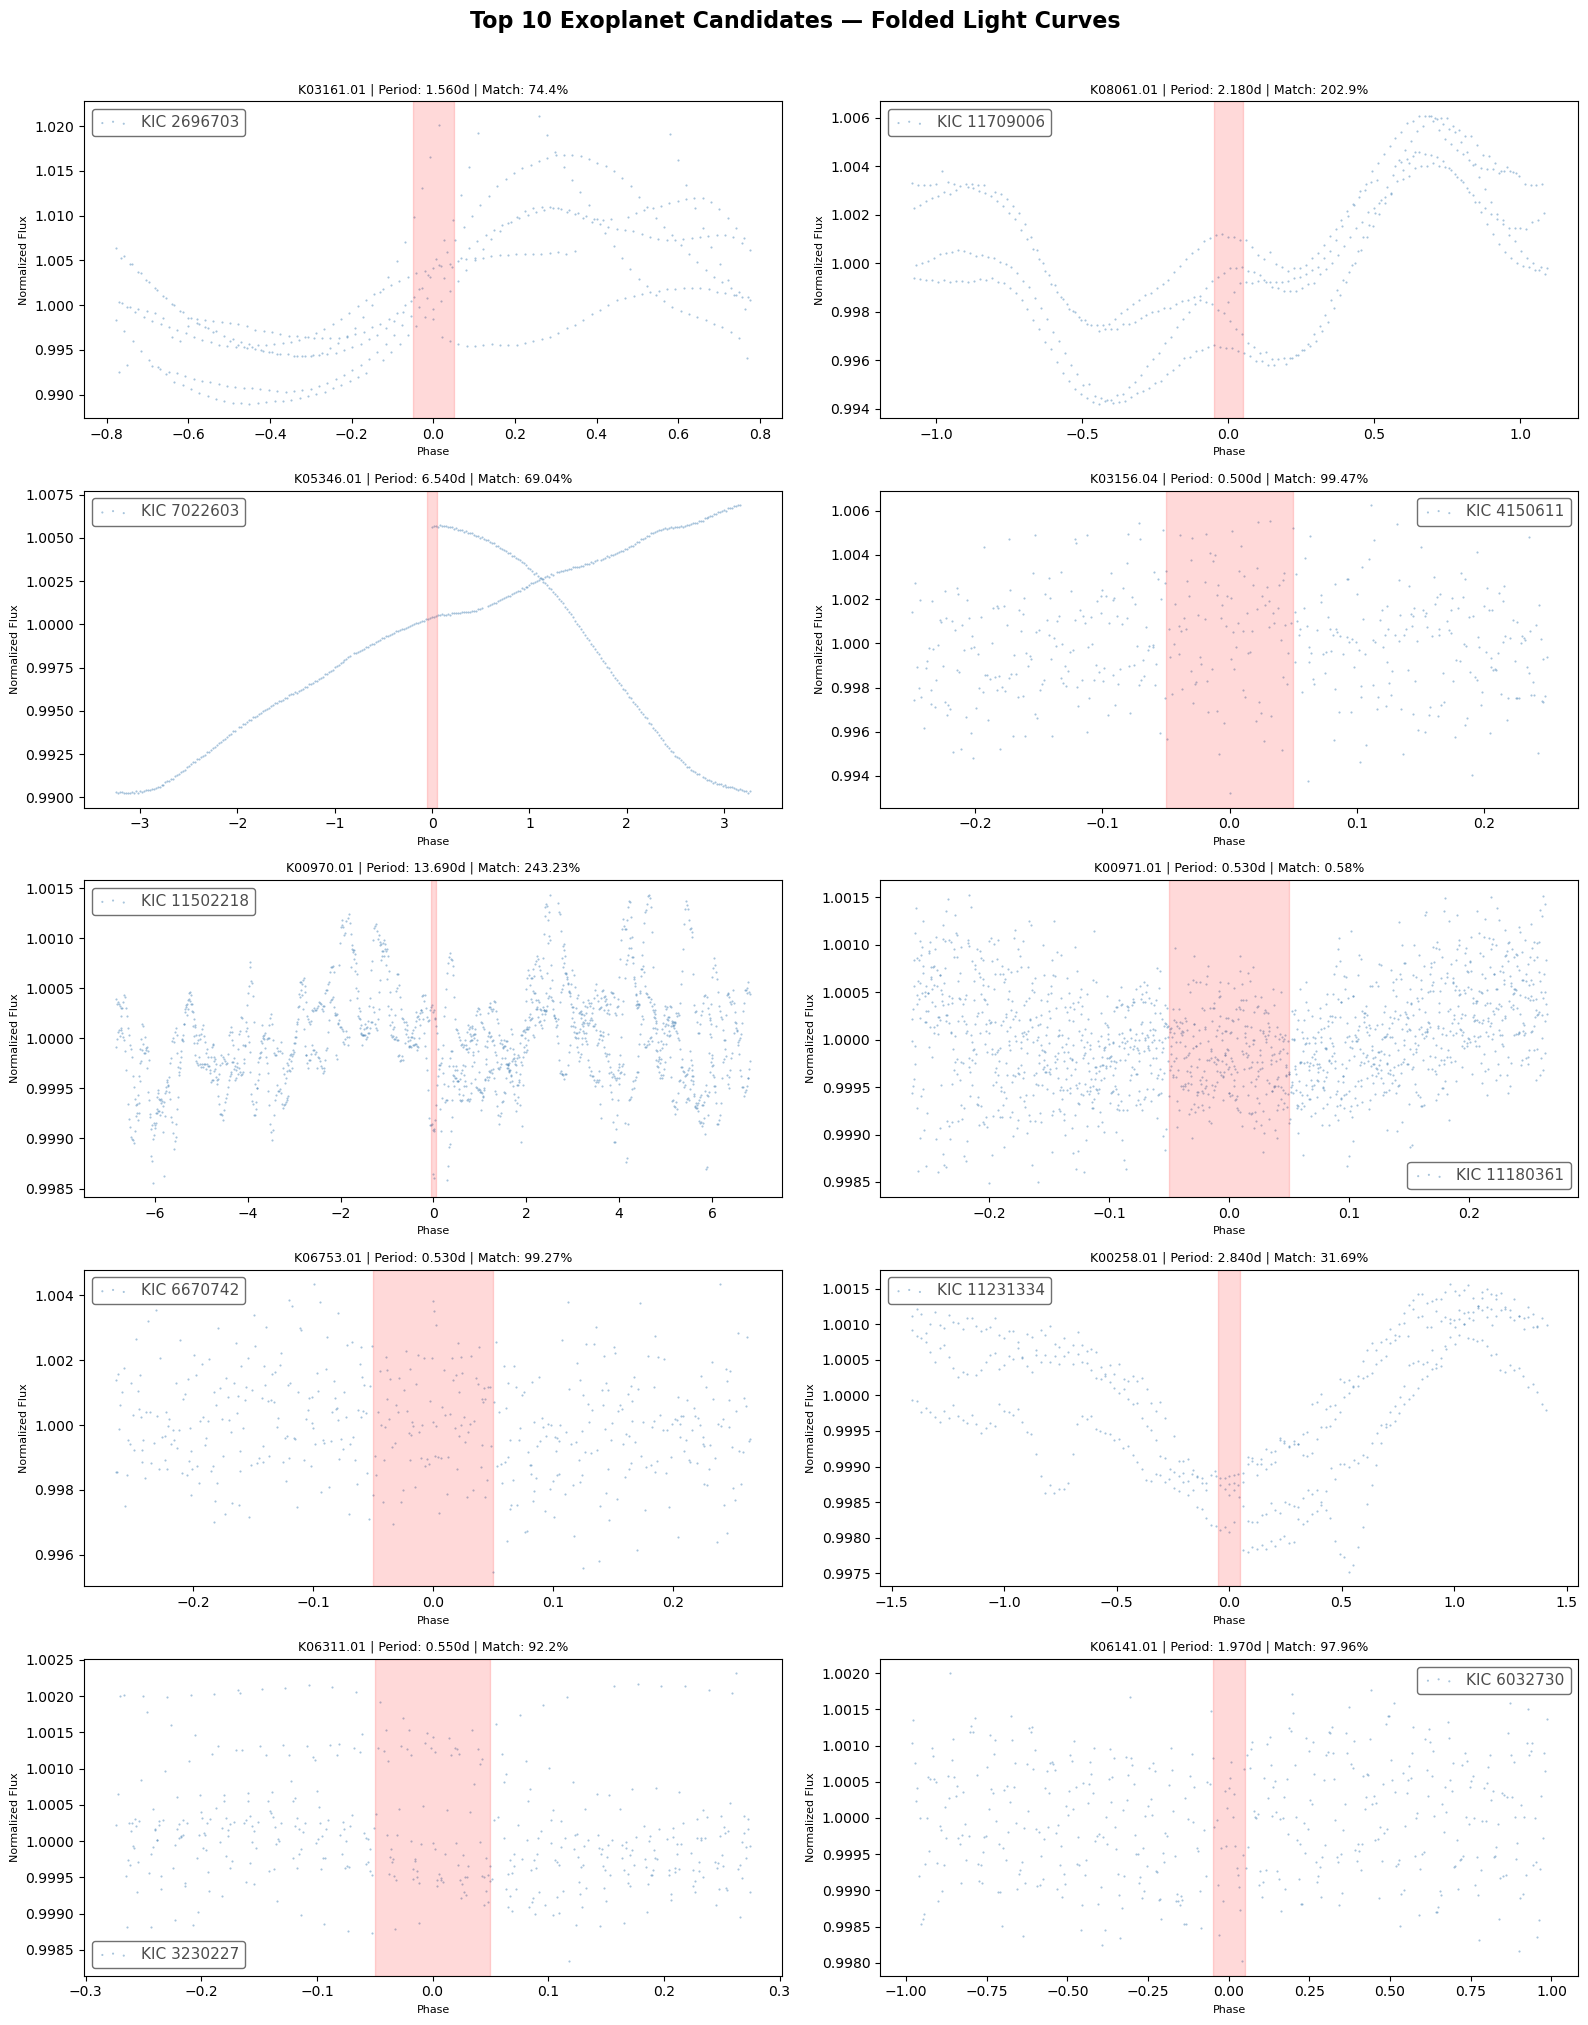

Plot saved to outputs/v2_top10_folded.png


In [18]:
results_clean = results_df_sorted.drop_duplicates(
    subset='kepid', keep='first'
).reset_index(drop=True)

top10 = results_clean.head(10)

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

fig.suptitle('Top 10 Exoplanet Candidates — Folded Light Curves', 
             fontsize=16, fontweight='bold', y=1.01)

for idx, row in top10.iterrows():
    kepid = str(int(row['kepid']))
    ax = axes[idx]
    
    try:
        search = lk.search_lightcurve(
            f"KIC {kepid}", 
            mission="Kepler", 
            cadence="long"
        )
        lc = search[0].download()
        lc = lc.remove_nans().remove_outliers(sigma=3).normalize()
        
        # Fold using detected period
        lc_folded = lc.fold(period=row['detected_period'])
        
        # Plot onto subplot
        lc_folded.scatter(ax=ax, s=1, alpha=0.5, color='steelblue')
        
        # Labels
        ax.set_title(
            f"{row['kepoi_name']} | Period: {row['detected_period']:.3f}d | "
            f"Match: {row['period_match']}%",
            fontsize=9
        )
        ax.set_xlabel("Phase", fontsize=8)
        ax.set_ylabel("Normalized Flux", fontsize=8)
        
        # Highlight the transit dip region
        ax.axvspan(-0.05, 0.05, alpha=0.15, color='red', 
                   label='Transit zone')
        
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {str(e)[:40]}", 
                transform=ax.transAxes, ha='center', fontsize=8)
        ax.set_title(f"{row['kepoi_name']} — data unavailable", fontsize=9)

plt.tight_layout()
plt.savefig('./outputs/v2_top10_folded.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to outputs/v2_top10_folded.png")

In [21]:
classifications = {
    'K00971.01': 'STRONG — period match 0.58%, consistent signal',
    'K00258.01': 'MODERATE — period match 31.69%, reasonable signal',
    'K03161.01': 'WEAK — period match 74.4%, poor fold',
    'K05346.01': 'FALSE POSITIVE — eclipsing binary signature',
    'K08061.01': 'FALSE POSITIVE — period match 202.9%',
    'K03156.04': 'FALSE POSITIVE — period match 99.47%',
    'K00970.01': 'FALSE POSITIVE — period match 243.23%',
    'K06753.01': 'FALSE POSITIVE — period match 99.27%',
    'K06311.01': 'WEAK — period match 92.2%',
    'K06141.01': 'FALSE POSITIVE — period match 97.96%'
}

print("CANDIDATE CLASSIFICATION SUMMARY")
print("=" * 60)
for name, classification in classifications.items():
    print(f"{name}: {classification}")

print(f"\nStrong candidates: 1/10 (10%)")
print(f"Moderate candidates: 1/10 (10%)")  
print(f"False positives / weak: 8/10 (80%)")
print(f"\nNote: ~80% false positive rate is consistent with")
print(f"real exoplanet survey pipelines before validation.")

results_df_sorted.to_csv('./outputs/v2_candidates.csv', index=False)
print("Results saved to outputs/v2_candidates.csv")


CANDIDATE CLASSIFICATION SUMMARY
K00971.01: STRONG — period match 0.58%, consistent signal
K00258.01: MODERATE — period match 31.69%, reasonable signal
K03161.01: WEAK — period match 74.4%, poor fold
K05346.01: FALSE POSITIVE — eclipsing binary signature
K08061.01: FALSE POSITIVE — period match 202.9%
K03156.04: FALSE POSITIVE — period match 99.47%
K00970.01: FALSE POSITIVE — period match 243.23%
K06753.01: FALSE POSITIVE — period match 99.27%
K06311.01: WEAK — period match 92.2%
K06141.01: FALSE POSITIVE — period match 97.96%

Strong candidates: 1/10 (10%)
Moderate candidates: 1/10 (10%)
False positives / weak: 8/10 (80%)

Note: ~80% false positive rate is consistent with
real exoplanet survey pipelines before validation.
Results saved to outputs/v2_candidates.csv
